# Gorilla Tag Sample Data: Access Check

Sanity check for the sample data a student sent in `test_data/` (see
`test_data/prompt.md` for the full description of the package). This notebook
just confirms that we can:

1. load her position and window-prediction CSVs,
2. run `phase_coordinates` on a real segment, and
3. plot a couple of simple comparisons.

This is **not** a reimplementation of her published cycle-segmentation
pipeline (window bridging, duration/amplitude filters, Savitzky-Golay
smoothing, etc. -- see `prompt.md` section 8). Cycle definition here comes
straight from `fit_pca_phase_coordinates`'s own Hilbert-phase estimate, just
to see the data and the algorithm talk to each other.

Units of the position data are not documented in `prompt.md`; axis labels
below are left unitless.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from phase_coordinates import fit_pca_phase_coordinates, reconstruct_phase_coordinates

In [2]:
DATA_DIR = Path("../test_data/repetitive_data")
SAMPLING_RATE_HZ = 60  # per test_data/prompt.md

# Sample selection -- participant 002 is the one full example we have.
SUBJECT, DAY, PART, TASK = 2, 1, "s", "w"  # day 1, start of practice, walking
TASK_NAME = {"w": "walk", "j": "jump", "c": "climb"}[TASK]
SOURCE_FILE = f"{SUBJECT:03d}-{DAY}-{PART}-{TASK}"
SOURCE_FILE

'002-1-s-w'

In [3]:
def longest_positive_run(window_predictions, source_file):
    """Merge overlapping/adjacent prediction==1 windows for one source file
    and return the (start_frame, end_frame) of the longest resulting run.

    This is a simple stand-in for the real pipeline's window-bridging step
    (prompt.md section 8), just enough to pick a plottable, mostly-positive
    stretch of frames.
    """
    rows = (
        window_predictions[
            (window_predictions["source_file"] == source_file)
            & (window_predictions["prediction"] == 1)
        ]
        .sort_values("start_frame")
    )

    runs = []
    cur_start, cur_end = None, None
    for _, row in rows.iterrows():
        s, e = int(row.start_frame), int(row.end_frame)
        if cur_start is None:
            cur_start, cur_end = s, e
        elif s <= cur_end:
            cur_end = max(cur_end, e)
        else:
            runs.append((cur_start, cur_end))
            cur_start, cur_end = s, e
    if cur_start is not None:
        runs.append((cur_start, cur_end))

    return max(runs, key=lambda r: r[1] - r[0])

In [4]:
window_predictions = pd.read_csv(DATA_DIR / f"window_predictions_{TASK_NAME}.csv")
start_frame, end_frame = longest_positive_run(window_predictions, SOURCE_FILE)
print(f"longest positive run for {SOURCE_FILE}: frames {start_frame}-{end_frame} "
      f"({(end_frame - start_frame) / SAMPLING_RATE_HZ:.1f} s)")

pos = pd.read_csv(DATA_DIR / "processed_data" / f"{SOURCE_FILE}_pos_aligned.csv")
print(f"loaded {SOURCE_FILE}_pos_aligned.csv: {pos.shape[0]} frames, {pos.shape[1]} columns")

# Cap the demo segment length so the plots stay readable.
MAX_DURATION_S = 20
seg_end = min(end_frame, start_frame + int(MAX_DURATION_S * SAMPLING_RATE_HZ))
seg = pos.iloc[start_frame:seg_end].reset_index(drop=True)
t = np.arange(len(seg)) / SAMPLING_RATE_HZ
seg.shape

longest positive run for 002-1-s-w: frames 0-1559 (26.0 s)
loaded 002-1-s-w_pos_aligned.csv: 10878 frames, 82 columns


(1200, 82)

## Comparison 1: hand height relative to root, both hands

`prompt.md` says cycle detection is based on `r_hand.y - root.y` and
`l_hand.y - root.y`. Just plotting both confirms the signals look like an
alternating walking gait, i.e. that we're reading the right columns.

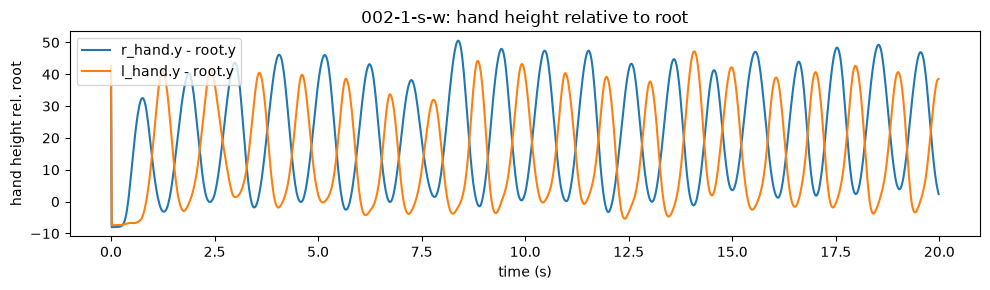

In [5]:
r_hand_y_rel = seg["r_hand.y"] - seg["root.y"]
l_hand_y_rel = seg["l_hand.y"] - seg["root.y"]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, r_hand_y_rel, label="r_hand.y - root.y")
ax.plot(t, l_hand_y_rel, label="l_hand.y - root.y")
ax.set_xlabel("time (s)")
ax.set_ylabel("hand height rel. root")
ax.set_title(f"{SOURCE_FILE}: hand height relative to root")
ax.legend()
plt.tight_layout()
plt.show()

## Run `fit_pca_phase_coordinates`

Phase comes from the Hilbert transform of `r_hand.y - root.y`; the fitted
geometry uses the 3-D right-hand position relative to the root.

In [6]:
X = np.column_stack([
    seg["r_hand.x"] - seg["root.x"],
    seg["r_hand.y"] - seg["root.y"],
    seg["r_hand.z"] - seg["root.z"],
])

samples, cycles, details = fit_pca_phase_coordinates(
    X,
    ref_signal=r_hand_y_rel.to_numpy(),
    sampling_rate_hz=SAMPLING_RATE_HZ,
    f_range=(0.5, 3.0),  # walking is roughly 1-2 Hz
)

print("samples:", samples.shape, " cycles:", cycles.shape)
cycles[["cycle", "n_samples", "duration", "radius_mean", "perp_mean", "fit_ok"]]

samples: (1200, 11)  cycles: (20, 25)


,cycle,n_samples,duration,radius_mean,perp_mean,fit_ok
0,0,64,1.066667,21.500540,-3.941292e-15,True
1,1,63,1.050000,17.697790,6.520357e-17,True
2,2,67,1.116667,16.646036,2.319869e-16,True
3,3,66,1.100000,17.817211,2.300348e-16,True
4,4,66,1.100000,17.345225,-3.582992e-16,True
5,5,64,1.066667,16.964835,1.332268e-15,True
6,6,62,1.033333,14.200222,5.980879e-16,True
7,7,66,1.100000,18.125577,-5.980065e-16,True
8,8,63,1.050000,17.726145,6.841970e-16,True
9,9,63,1.050000,16.720642,-3.630253e-16,True


## Comparison 2: phase-coordinate outputs over time

Sanity-check that phase/radius/perp look like plausible cyclic output rather
than noise or all-NaN.

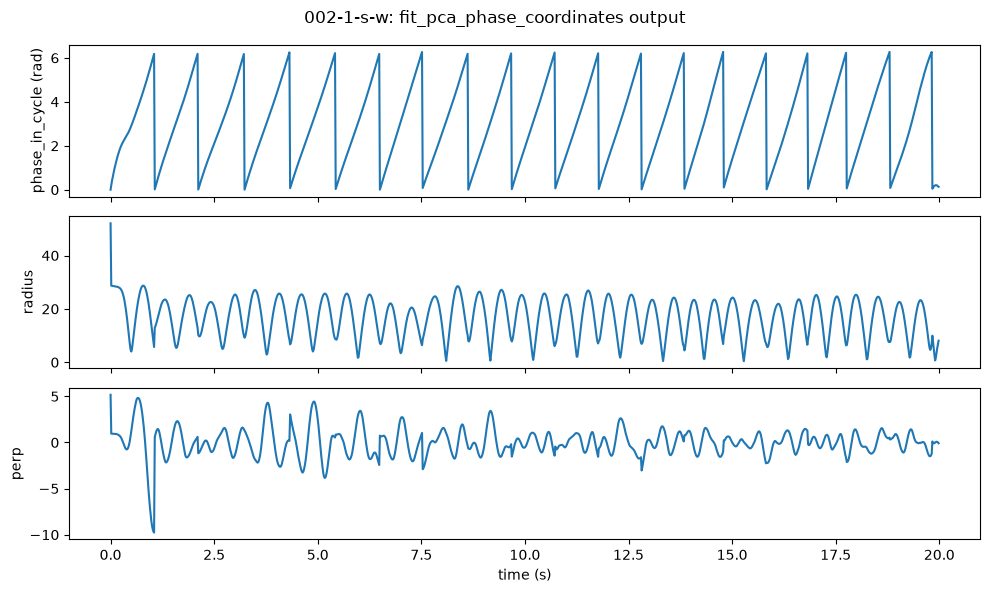

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(samples["time"], samples["phase_in_cycle"])
axes[0].set_ylabel("phase_in_cycle (rad)")
axes[1].plot(samples["time"], samples["radius"])
axes[1].set_ylabel("radius")
axes[2].plot(samples["time"], samples["perp"])
axes[2].set_ylabel("perp")
axes[2].set_xlabel("time (s)")
fig.suptitle(f"{SOURCE_FILE}: fit_pca_phase_coordinates output")
plt.tight_layout()
plt.show()

## Comparison 3: original vs. reconstructed trajectory

With exactly 3 input features, PCA reconstruction should match the input to
near machine precision -- this just confirms the round trip works on real
data (not only the synthetic demo signal in `notebooks/pca_phase_coordinates_demo.ipynb`).

1200/1200 samples reconstructed; max error = 3.31e-14


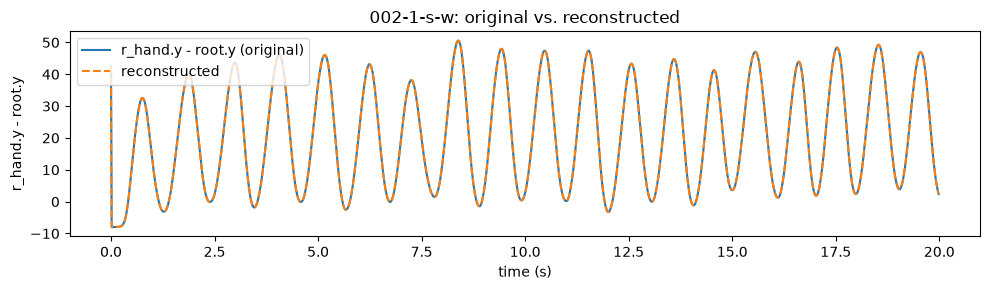

In [8]:
X_hat = reconstruct_phase_coordinates(samples, cycles)
fitted = ~np.isnan(X_hat[:, 0])
err = np.linalg.norm(X_hat[fitted] - X[fitted], axis=1)
print(f"{fitted.sum()}/{len(fitted)} samples reconstructed; "
      f"max error = {err.max():.2e}" if fitted.any() else "no samples reconstructed")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, X[:, 1], label="r_hand.y - root.y (original)")
ax.plot(t[fitted], X_hat[fitted, 1], "--", label="reconstructed")
ax.set_xlabel("time (s)")
ax.set_ylabel("r_hand.y - root.y")
ax.set_title(f"{SOURCE_FILE}: original vs. reconstructed")
ax.legend()
plt.tight_layout()
plt.show()

## Comparison 4: quick look across movement types

Just confirming we can load walk/jump/climb data for the same
participant/session without touching the segmentation pipeline.

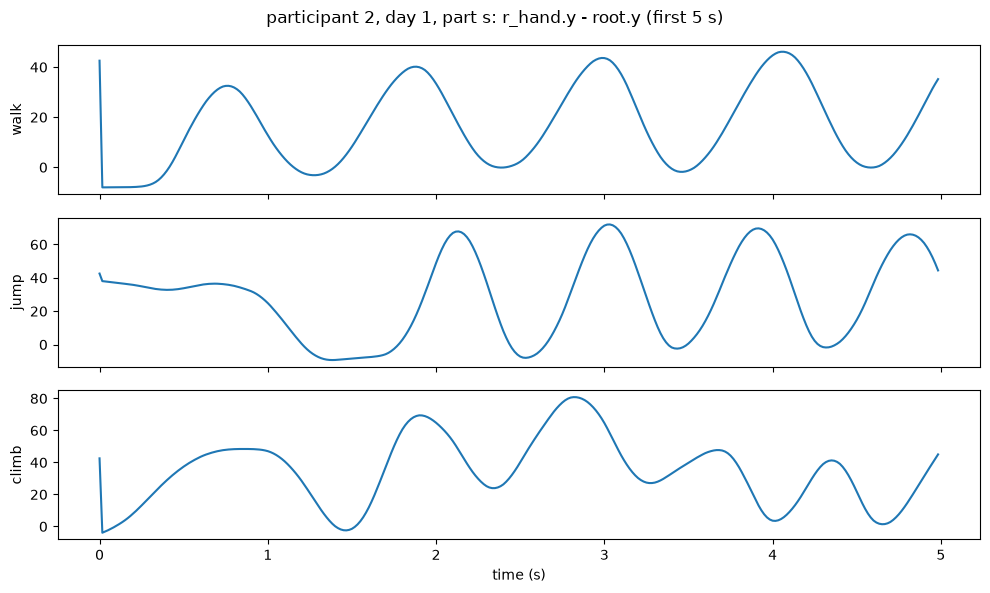

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True, sharey=False)
for ax, code in zip(axes, ["w", "j", "c"]):
    task_name = {"w": "walk", "j": "jump", "c": "climb"}[code]
    src = f"{SUBJECT:03d}-{DAY}-{PART}-{code}"
    df = pd.read_csv(DATA_DIR / "processed_data" / f"{src}_pos_aligned.csv", nrows=300)
    t_short = np.arange(len(df)) / SAMPLING_RATE_HZ
    ax.plot(t_short, df["r_hand.y"] - df["root.y"])
    ax.set_ylabel(task_name)
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"participant {SUBJECT}, day {DAY}, part {PART}: r_hand.y - root.y (first 5 s)")
plt.tight_layout()
plt.show()

## Bayesian algorithm (optional, guarded)

`fit_bayesian_phase_coordinates` needs the optional `pymc`/`arviz`
dependencies (the `bayes` pixi environment: `pixi run -e bayes jupyter lab`)
and runs MCMC, which is slow. This cell only runs it if those deps are
already importable in the current kernel; otherwise it just reports that
it's skipped, rather than installing anything or waiting on a long sample.

In [10]:
try:
    import pymc  # noqa: F401
    import arviz  # noqa: F401
    HAVE_BAYES_DEPS = True
except ImportError:
    HAVE_BAYES_DEPS = False

if not HAVE_BAYES_DEPS:
    print("pymc/arviz not installed in this kernel -- skipping. "
          "Run this notebook under `pixi run -e bayes jupyter lab` to try it.")
else:
    from phase_coordinates import fit_bayesian_phase_coordinates

    b_samples, b_cycles, b_details = fit_bayesian_phase_coordinates(
        X[:300],  # short slice: this is just a smoke test, not a real fit
        sampling_rate_hz=SAMPLING_RATE_HZ,
        draws=200,
        tune=200,
        chains=2,
        random_seed=0,
    )
    print("bayesian samples:", b_samples.shape, " cycles:", b_cycles.shape)

pymc/arviz not installed in this kernel -- skipping. Run this notebook under `pixi run -e bayes jupyter lab` to try it.
